In [2]:
from datetime import date, timedelta

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from charts import (
    Candles,
    CompareVIX,
    DirectionalGammaImbalance,
    GrossGEX,
    OpenInterestComparison,
    StrikeGammaSingleExp,
    VolumeByExpiry,
    VolumeDelta,
)

In [148]:
DATA_DIR = "../../../.tickrake/data/options/schwab"

In [ ]:
comp_vix = CompareVIX(data_dir=DATA_DIR, interval=5)
comp_vix_df = comp_vix.load_data()
fig, ax = comp_vix.plot(figsize=(8, 6))

Latest snapshot file: ../data/SPXW_exp2026-01-16_2026-01-15_14-32-00.csv
Previous snapshot file: ../data/SPXW_exp2026-01-16_2026-01-15_12-01-45.csv


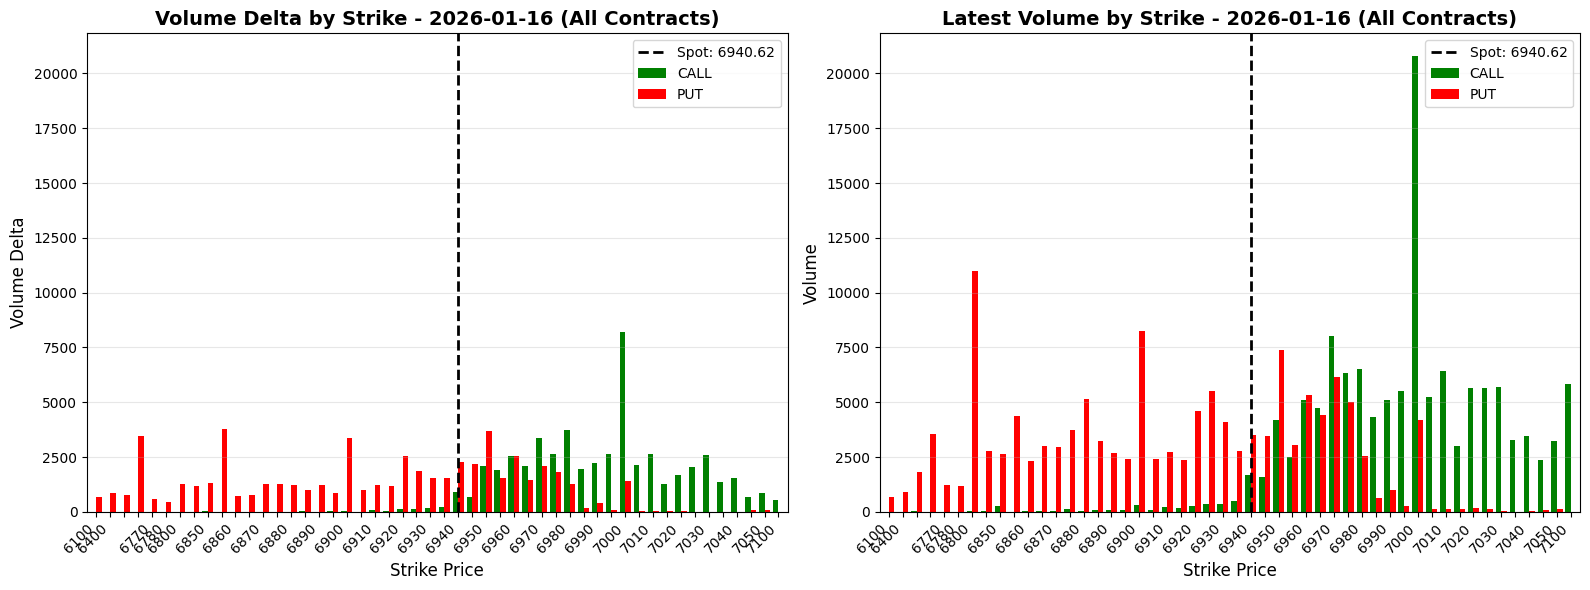

In [57]:
vol_delta = VolumeDelta(data_dir=DATA_DIR)
vol_delta_df = vol_delta.load_data(symbol="SPXW", expiration_date="2026-01-16", lookback=5)
fig, ax = vol_delta.plot(top_n_strikes=50, contract_type="ALL", figsize=(16, 6))

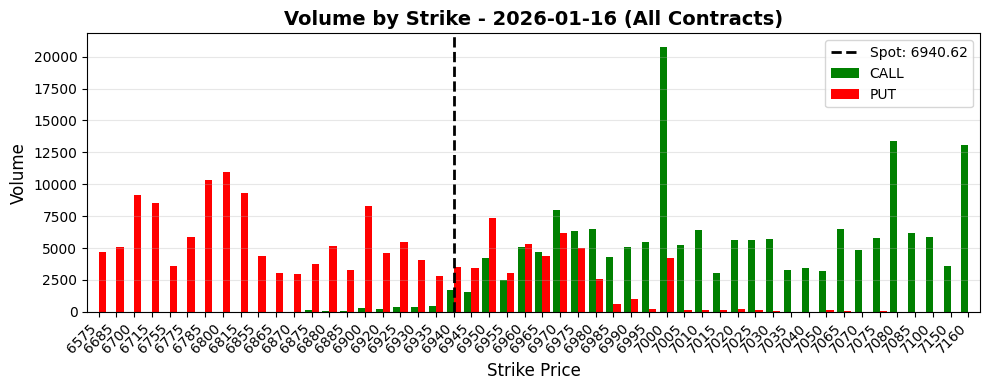

In [58]:
chart = VolumeByExpiry(data_dir="../data")
chart.load_data(symbol="SPXW", expiration_date="2026-01-16")
fig, ax = chart.plot(top_n_strikes=50, contract_type="ALL", figsize=(10, 4))

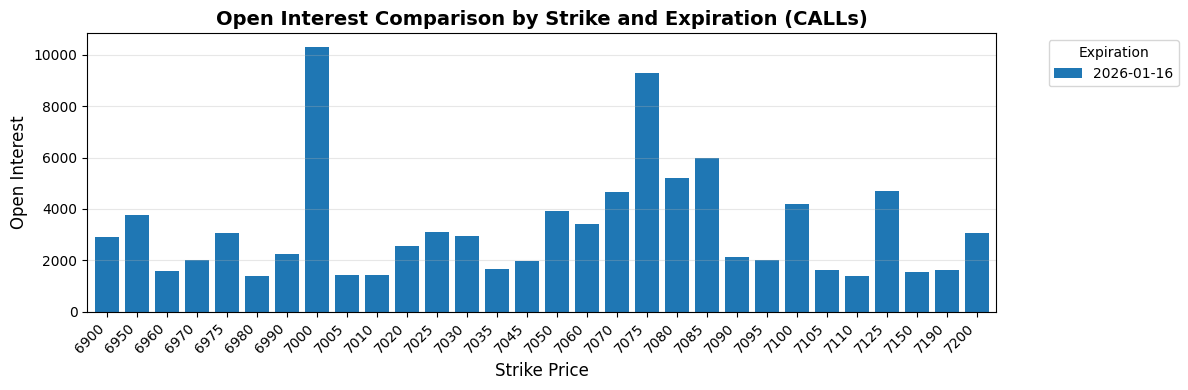

In [59]:
chart = OpenInterestComparison(data_dir="../data")
chart.load_data(symbol="SPXW", start_date="2026-01-16", days_out=2)
fig, ax = chart.plot(
    min_strike=6500, max_strike=7200, top_n_strikes=30, contract_type="CALL", figsize=(12, 4)
)

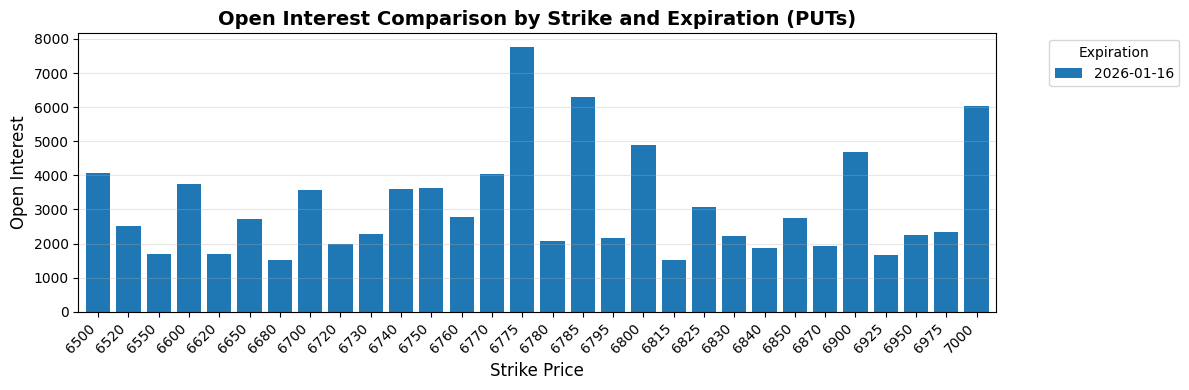

In [60]:
chart = OpenInterestComparison(data_dir="../data")
chart.load_data(symbol="SPXW", start_date="2026-01-16", days_out=1)
fig, ax = chart.plot(
    min_strike=6500, max_strike=7200, top_n_strikes=30, contract_type="PUT", figsize=(12, 4)
)

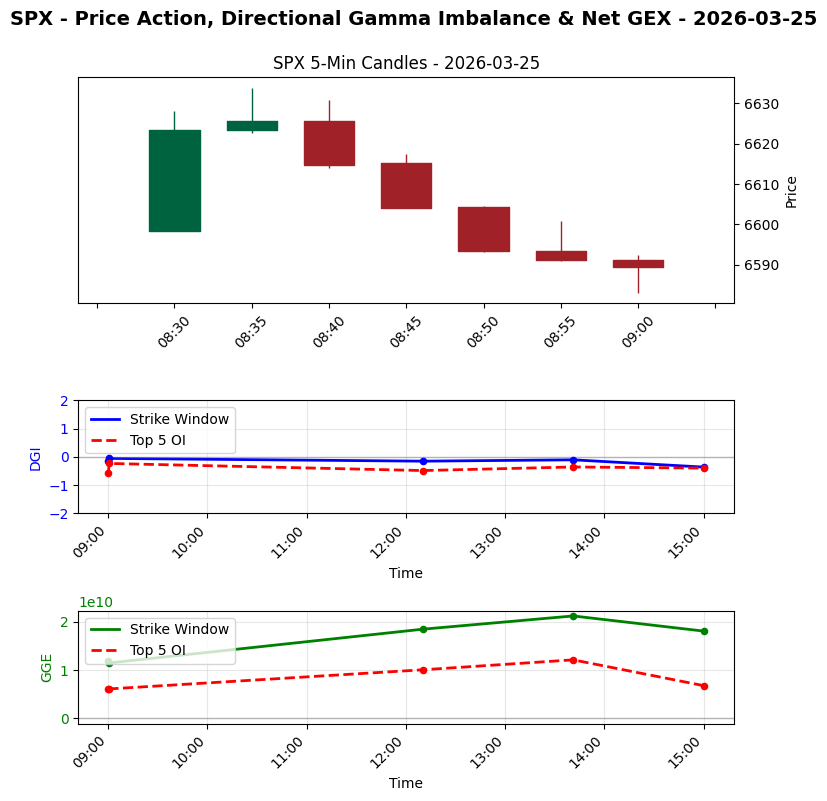

In [143]:
SYMBOL = "SPX"
SYMBOL_OPTIONS = "SPXW"
DATE = "2026-03-25"
EXP_DATE = "2026-03-25"
DATA_DIR = "../data"

# Create a figure with three independent subplots (3 rows, 1 column)
fig, (ax_candles, ax_dgi, ax_gex) = plt.subplots(
    3,
    1,
    figsize=(8, 8),
    gridspec_kw={"height_ratios": [2, 1, 1]},  # Candles: 50%, DGI: 25%, NetGEX: 25%
)

# ========================================
# Top subplot: Candlestick chart
# ========================================
candles = Candles.from_file(symbol=SYMBOL, date=DATE, interval=5, data_dir=DATA_DIR)

# Plot on the provided axis
candles.plot(symbol=SYMBOL, interval=5, ax=ax_candles)

# ========================================
# Middle subplot: Directional Gamma Imbalance
# ========================================
dgi_chart = DirectionalGammaImbalance(data_dir=DATA_DIR)
dgi_chart.load_and_calculate(symbol=SYMBOL_OPTIONS, expiration_filter=EXP_DATE, sample_date=DATE)

# Plot DGI on the middle axis
ax_dgi.plot(dgi_chart.timestamps, dgi_chart.dgi_scores, "b-", linewidth=2, label="Strike Window")
ax_dgi.scatter(dgi_chart.timestamps, dgi_chart.dgi_scores, c="blue", s=20, zorder=5)

# Plot Top 5 OI Strikes DGI if available
if dgi_chart.top5_dgi_scores:
    ax_dgi.plot(
        dgi_chart.timestamps,
        dgi_chart.top5_dgi_scores,
        "r--",
        linewidth=2,
        label="Top 5 OI",
    )
    ax_dgi.scatter(dgi_chart.timestamps, dgi_chart.top5_dgi_scores, c="red", s=20, zorder=5)

ax_dgi.axhline(y=0, color="gray", linestyle="-", linewidth=1, alpha=0.5)

# Format the DGI subplot
ax_dgi.set_xlabel("Time")
ax_dgi.set_ylabel("DGI", color="b")
ax_dgi.tick_params(axis="y", labelcolor="b")
ax_dgi.set_ylim(-2.0, 2.0)
ax_dgi.grid(True, alpha=0.3)
ax_dgi.legend(loc="upper left")

# Format x-axis for time display
ax_dgi.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_dgi.xaxis.set_major_locator(mdates.AutoDateLocator())

# ========================================
# Bottom subplot: Gross GEX
# ========================================
gex_chart = GrossGEX(data_dir=DATA_DIR)
gex_chart.load_and_calculate(symbol=SYMBOL_OPTIONS, expiration_filter=EXP_DATE, sample_date=DATE)

# Plot Gross GEX on the bottom axis
ax_gex.plot(
    gex_chart.timestamps, gex_chart.net_gex_values, "g-", linewidth=2, label="Strike Window"
)
ax_gex.scatter(gex_chart.timestamps, gex_chart.net_gex_values, c="green", s=20, zorder=5)

# Plot Top 5 OI Strikes GEX if available
if gex_chart.top5_gex_values:
    ax_gex.plot(
        gex_chart.timestamps,
        gex_chart.top5_gex_values,
        "r--",
        linewidth=2,
        label="Top 5 OI",
    )
    ax_gex.scatter(gex_chart.timestamps, gex_chart.top5_gex_values, c="red", s=20, zorder=5)

ax_gex.axhline(y=0, color="gray", linestyle="-", linewidth=1, alpha=0.5)

# Format the Gross GEX subplot
ax_gex.set_xlabel("Time")
ax_gex.set_ylabel("GGE", color="g")
ax_gex.tick_params(axis="y", labelcolor="g")
ax_gex.grid(True, alpha=0.3)
ax_gex.legend(loc="upper left")

# Format x-axis for time display
ax_gex.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax_gex.xaxis.set_major_locator(mdates.AutoDateLocator())

# ========================================
# Final adjustments
# ========================================
# Add overall title
fig.suptitle(
    f"{SYMBOL} - Price Action, Directional Gamma Imbalance & Net GEX - {DATE}",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)

# Rotate x-axis labels for all subplots
plt.setp(ax_dgi.xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.setp(ax_gex.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

exp dates:  [datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29), datetime.date(2026, 4, 30), datetime.date(2026, 5, 1), datetime.date(2026, 5, 4), datetime.date(2026, 5, 5)]
Strike range: 6600-7300
Total Call Gamma Exposure: 32,831,125,752
Total Put Gamma Exposure:  13,403,289,197


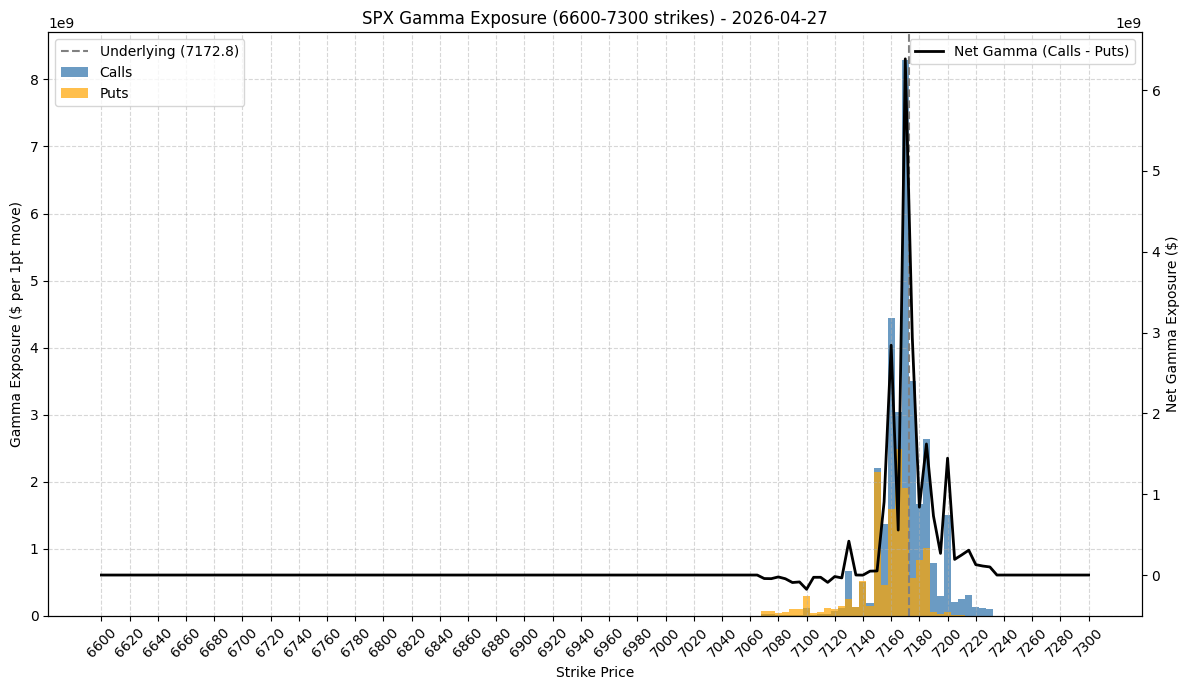

Strike range: 6600-7300
Total Call Gamma Exposure: 7,251,662,306
Total Put Gamma Exposure:  2,322,880,080


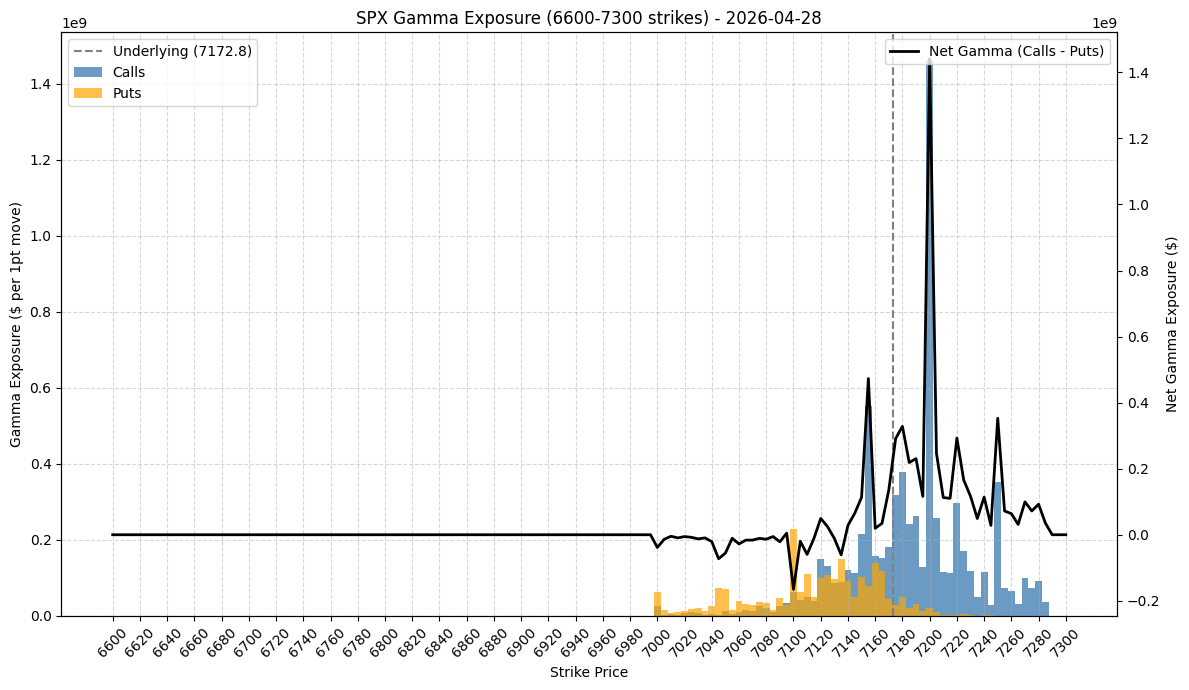

Strike range: 6600-7300
Total Call Gamma Exposure: 4,467,128,525
Total Put Gamma Exposure:  1,785,853,296


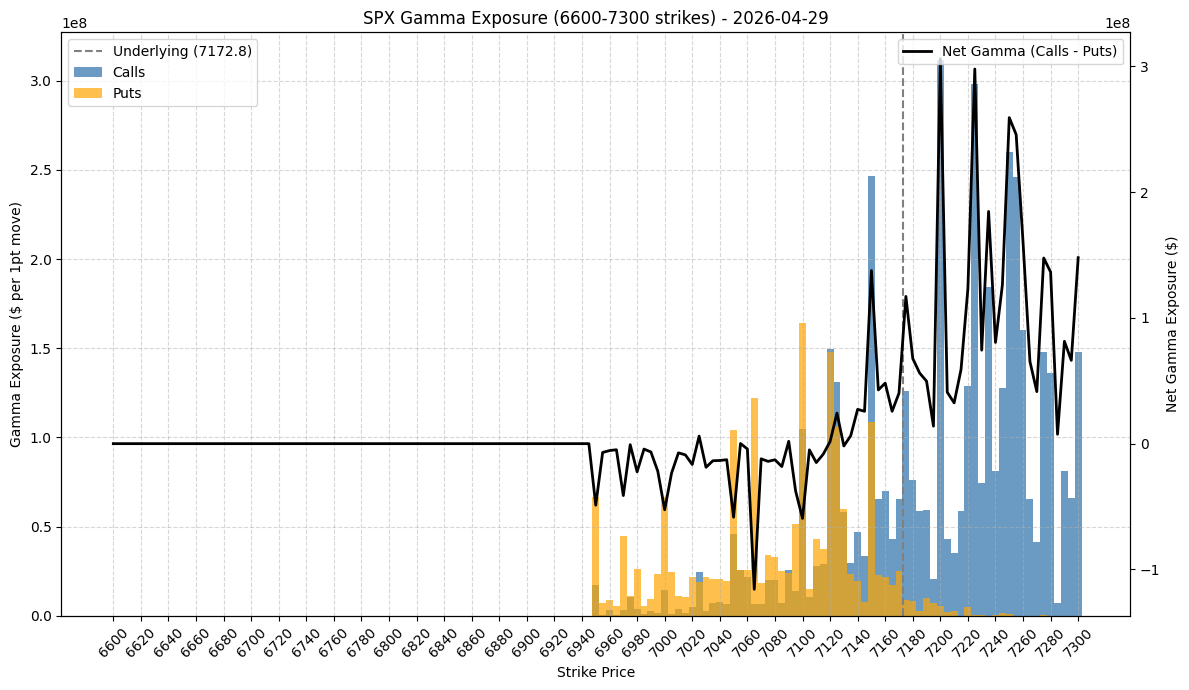

Strike range: 6600-7300
Total Call Gamma Exposure: 11,928,189,089
Total Put Gamma Exposure:  3,919,760,452


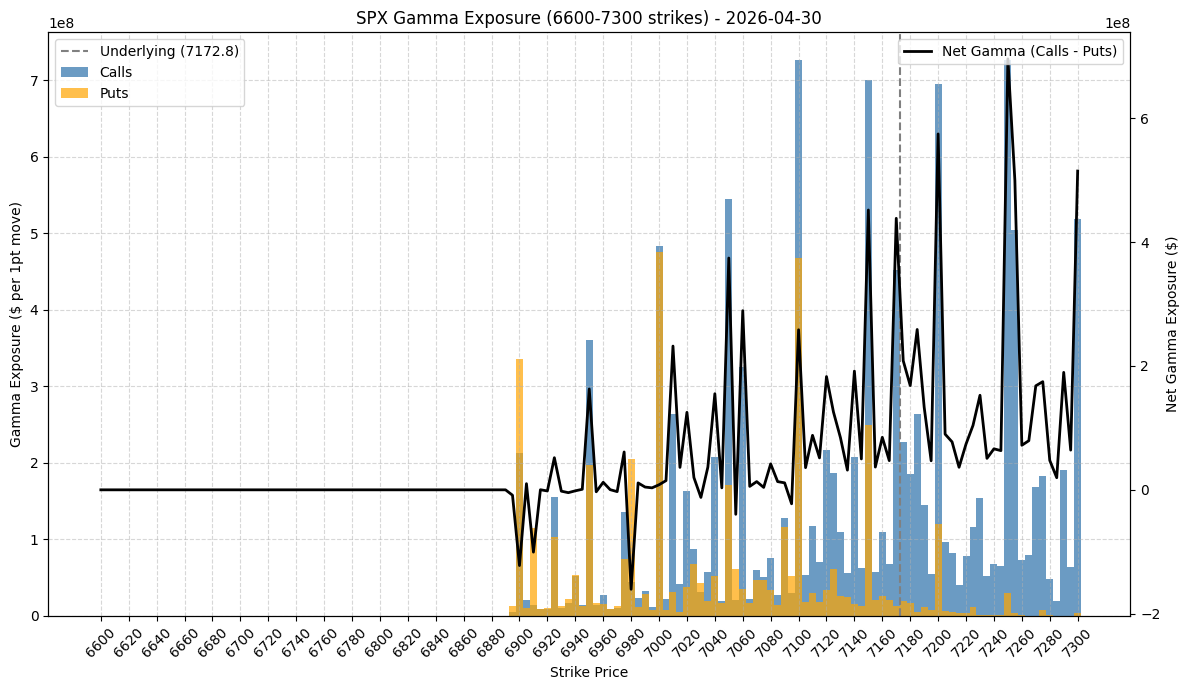

Strike range: 6600-7300
Total Call Gamma Exposure: 9,351,121,073
Total Put Gamma Exposure:  5,094,269,370


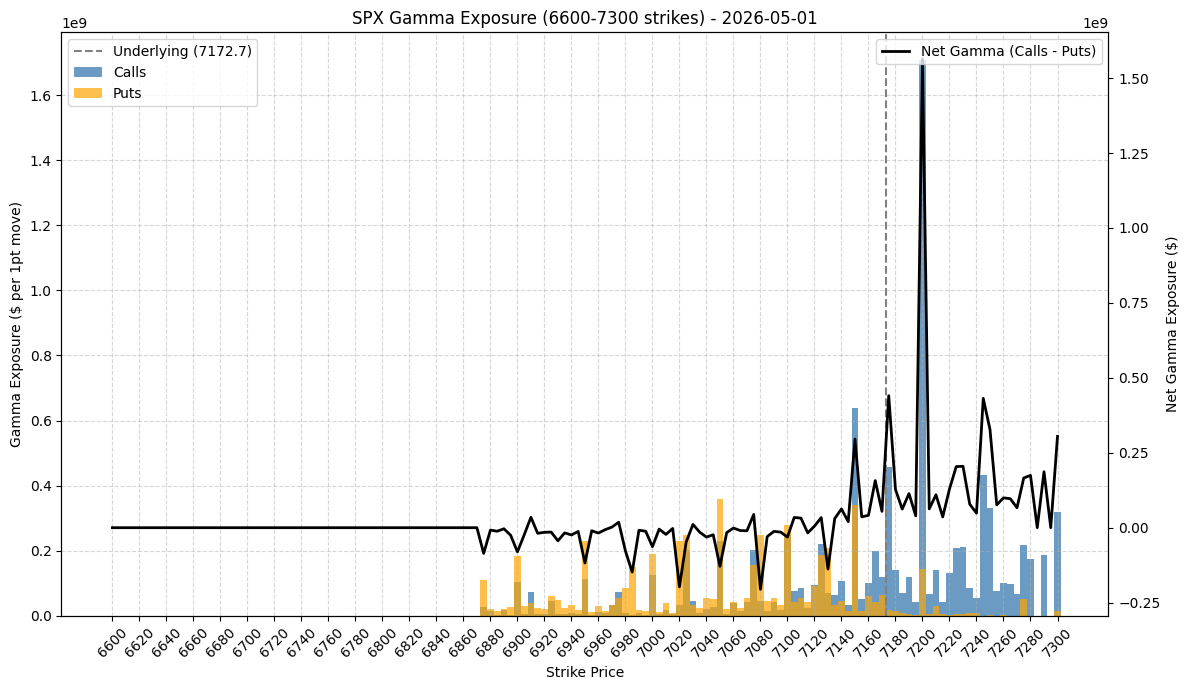

Strike range: 6600-7300
Total Call Gamma Exposure: 2,304,917,914
Total Put Gamma Exposure:  1,172,600,815


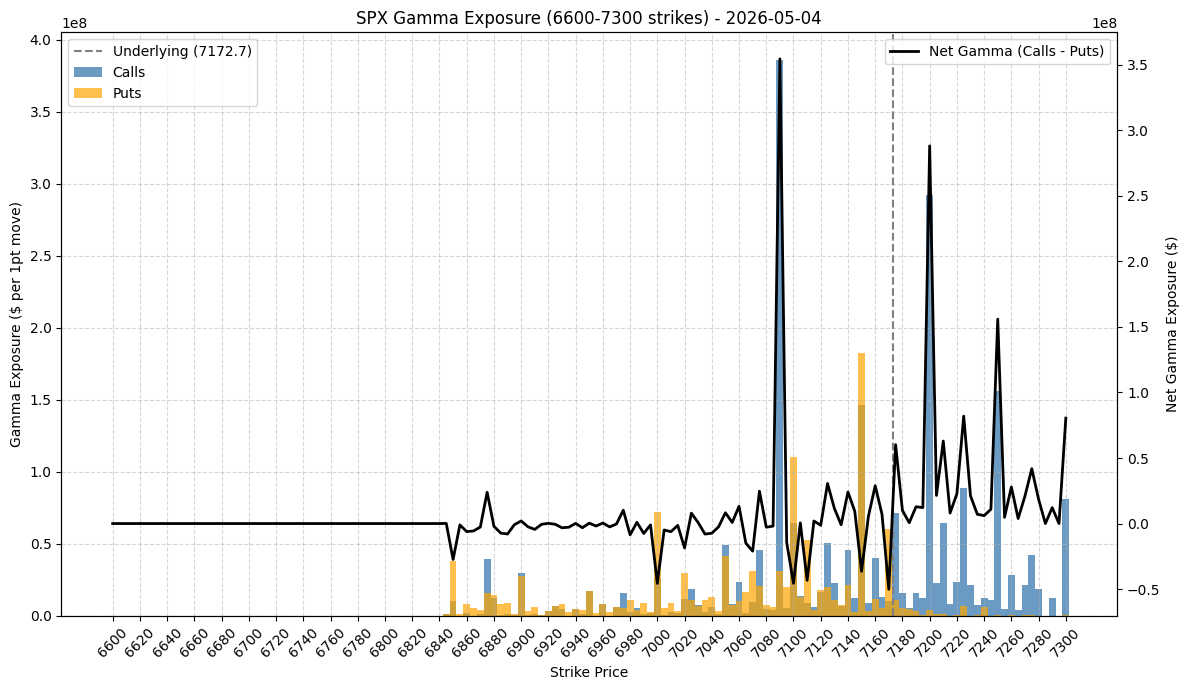

Strike range: 6600-7300
Total Call Gamma Exposure: 911,348,317
Total Put Gamma Exposure:  864,222,029


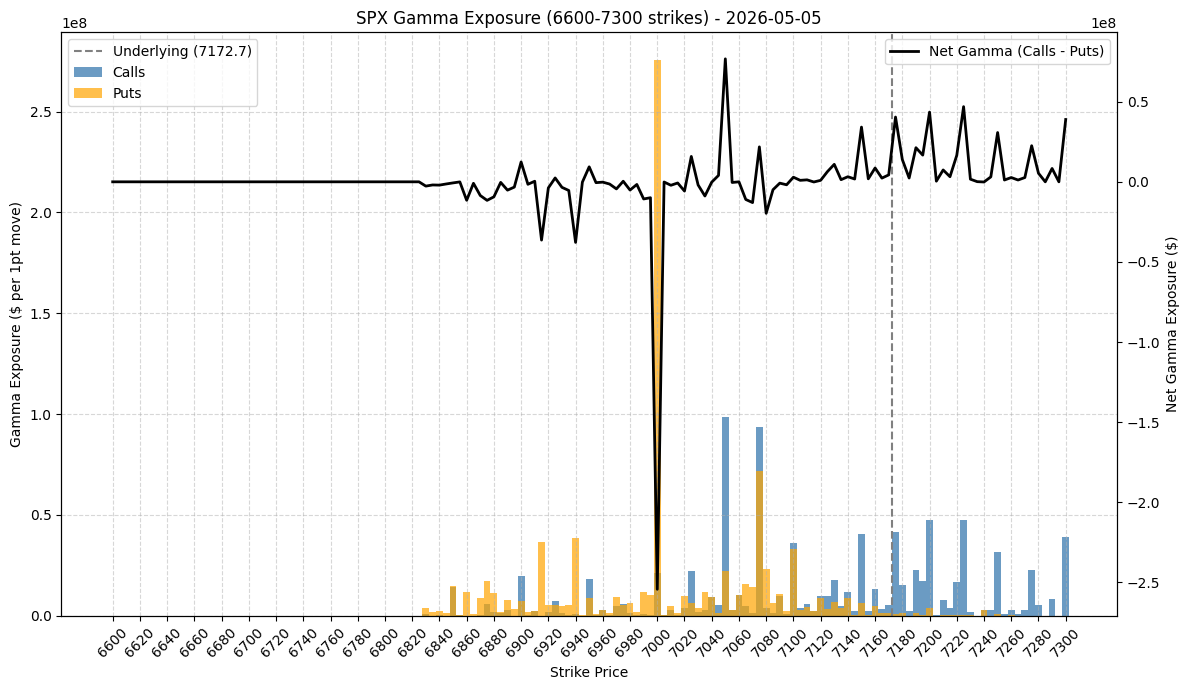

In [174]:
holidays = {date(2025, 12, 25), date(2026, 1, 1), date(2026, 1, 19), date(2026, 2, 16)}

today = date.today()
min_strike = 6600
max_strike = 7300

expiration_dates = []
current = today

while len(expiration_dates) < 7:
    if current.weekday() < 5 and current not in holidays:
        expiration_dates.append(current)
    current += timedelta(days=1)

print("exp dates: ", expiration_dates)
for expiration_date in expiration_dates:
    try:
        gex = StrikeGammaSingleExp(
            symbol="SPXW", expiration_date=expiration_date, data_dir=DATA_DIR
        )

        fig, axes = gex.plot(
            min_strike=min_strike, max_strike=max_strike, date=expiration_date, figsize=(12, 7)
        )
    except Exception as e:
        print(e)